Dataset Shape: (284807, 31)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20  

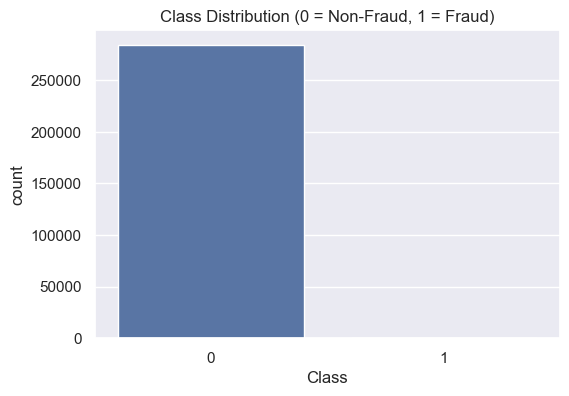

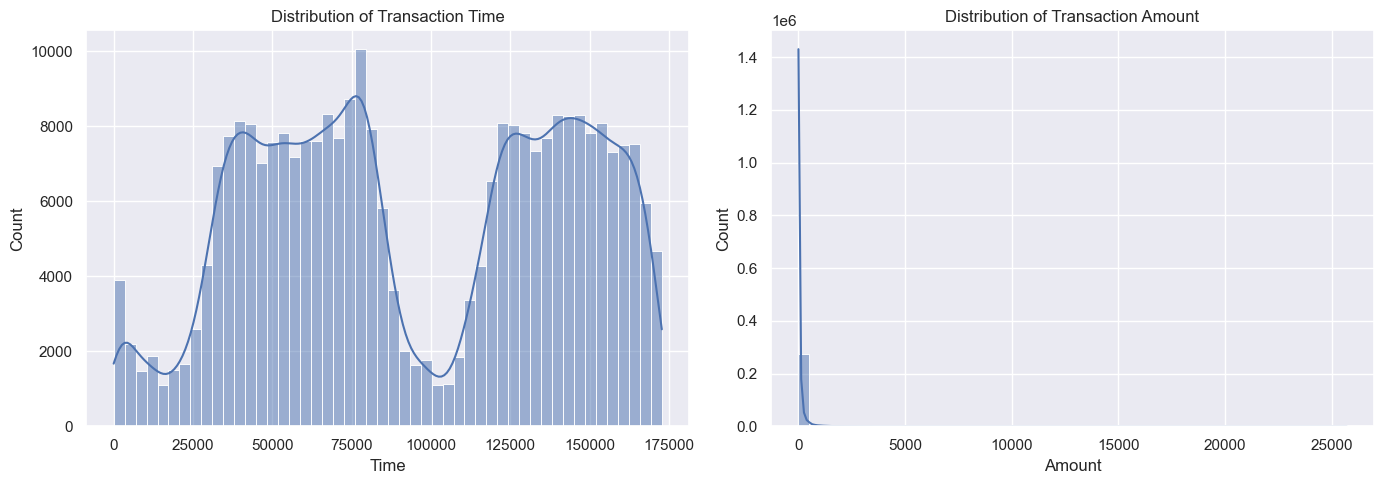

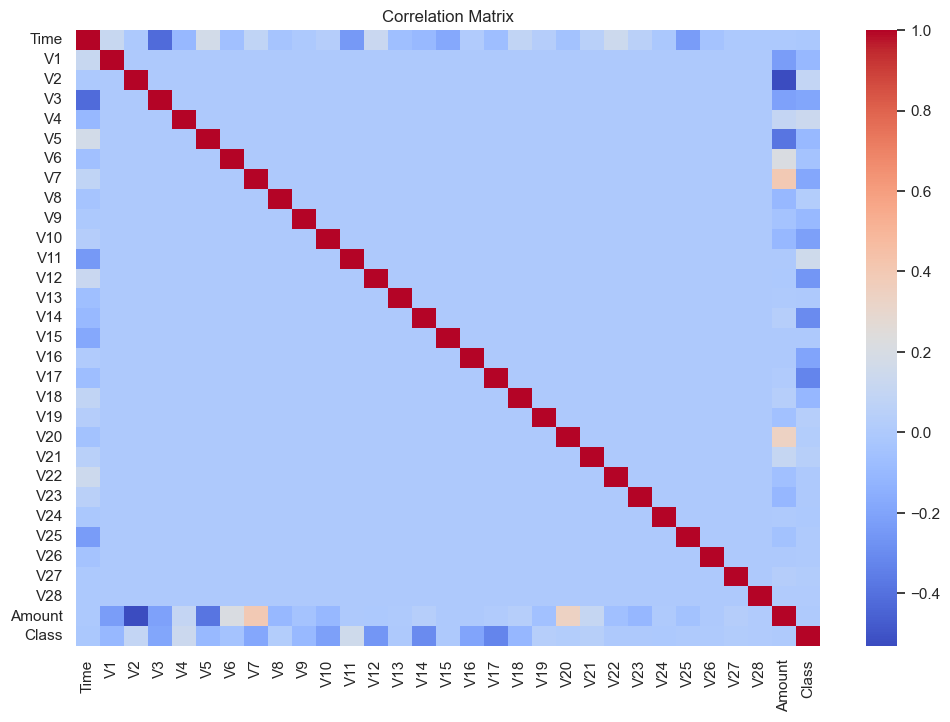


Top 10 Features Correlated with Class:
V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485
Name: Class, dtype: float64


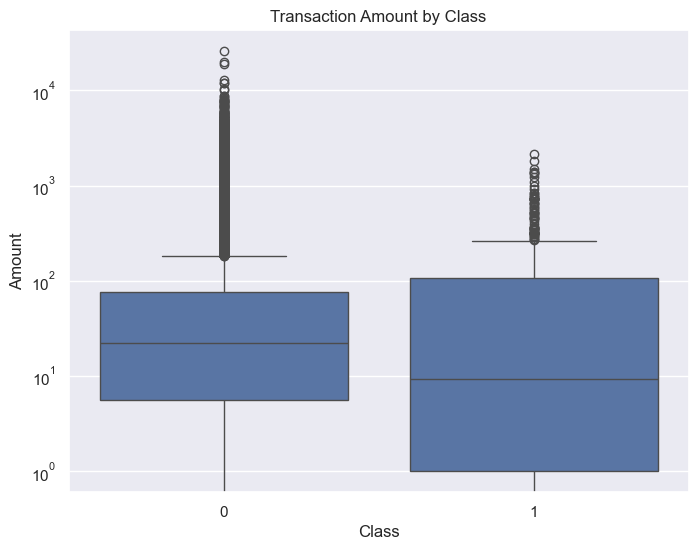

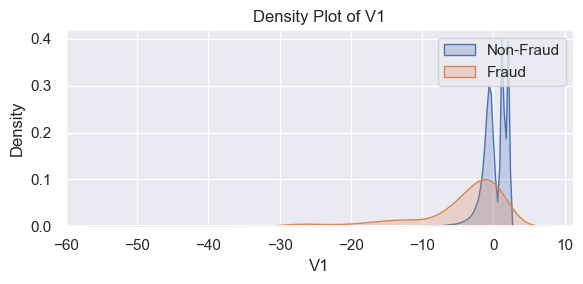

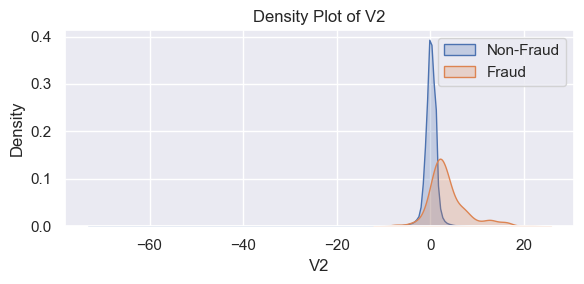

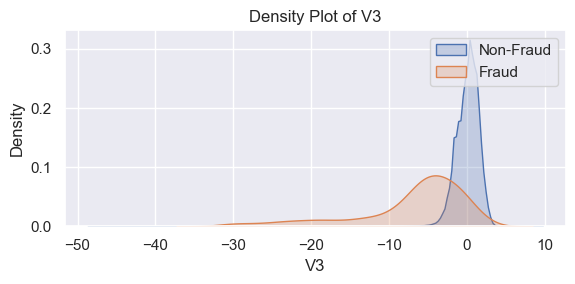

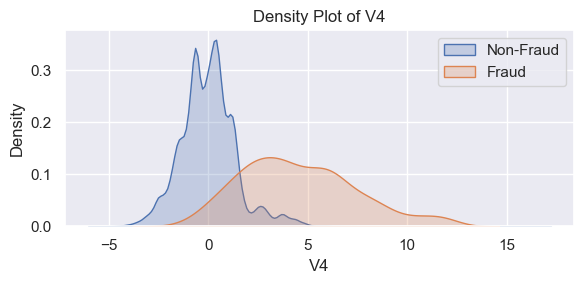

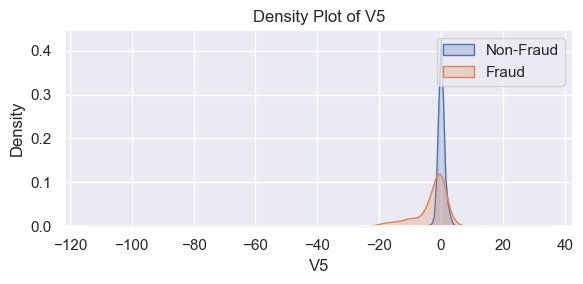

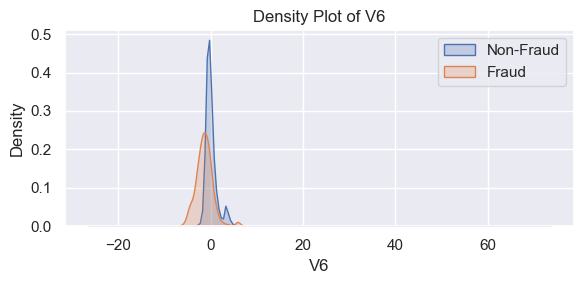

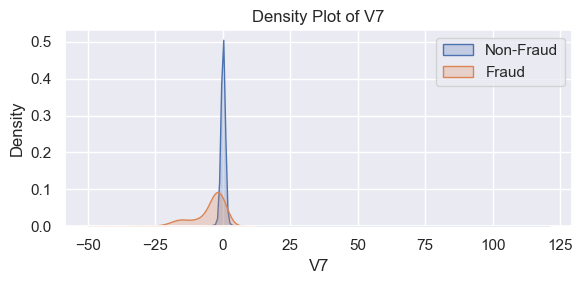

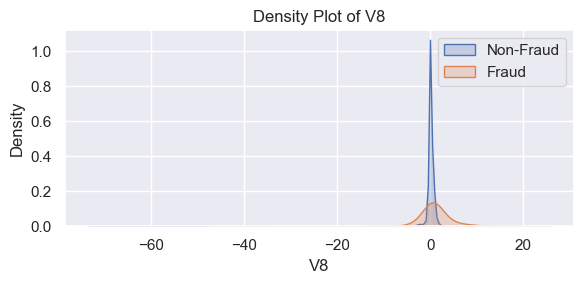

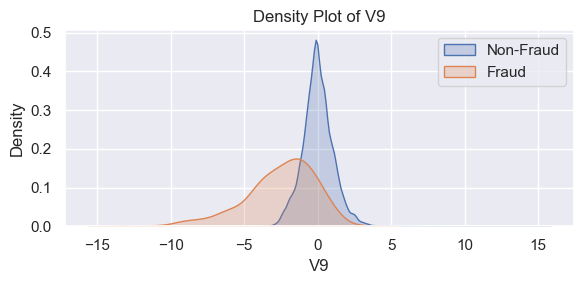

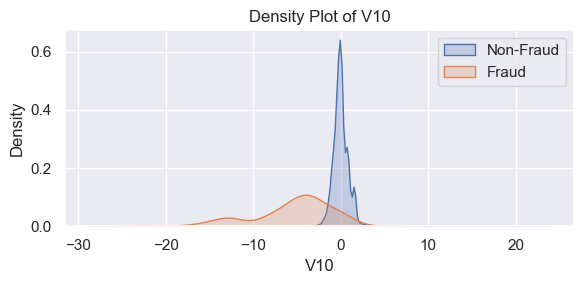

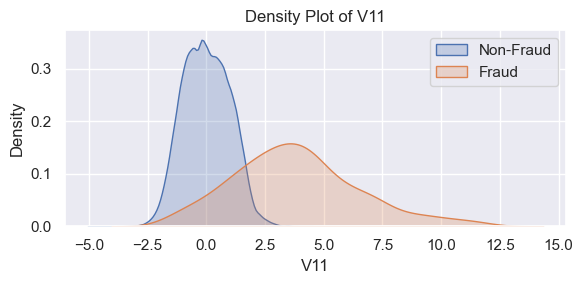

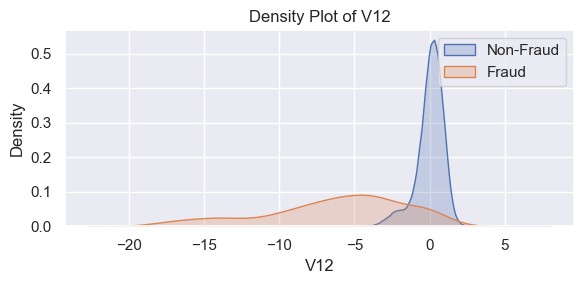

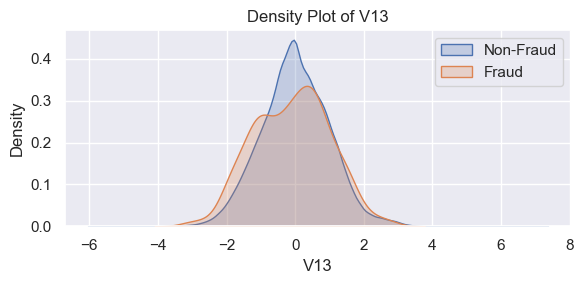

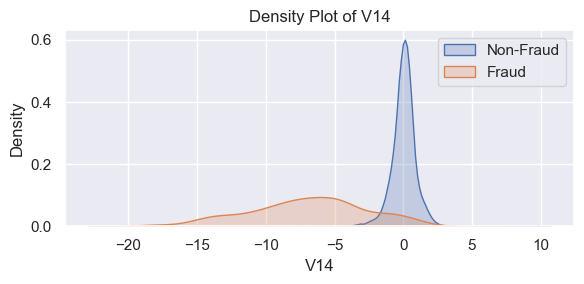

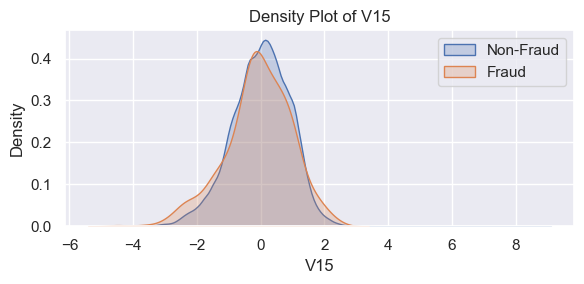

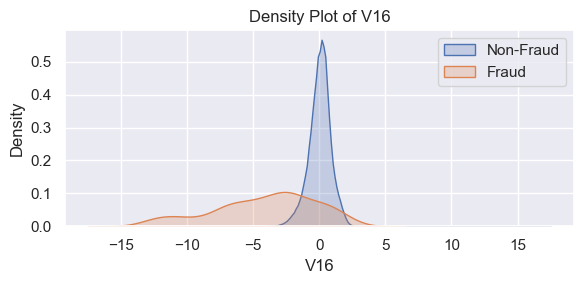

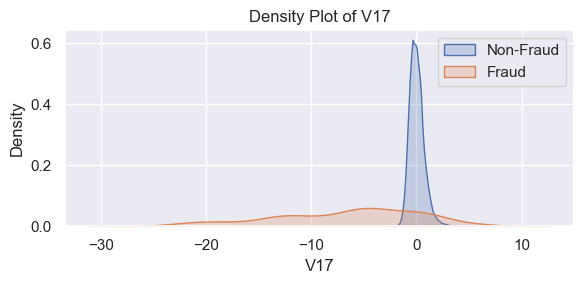

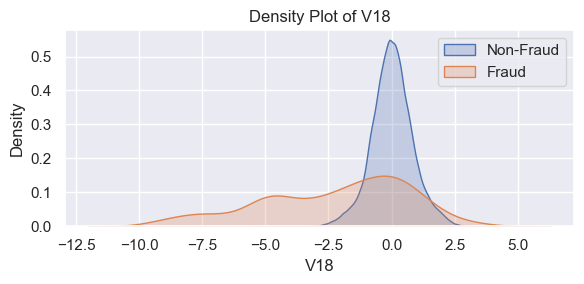

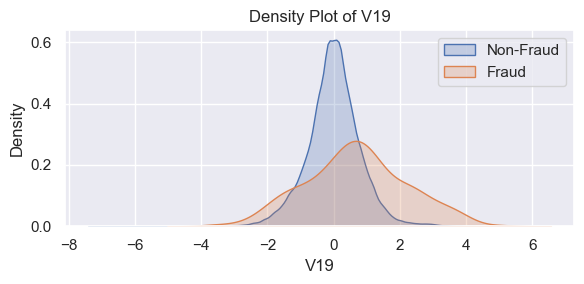

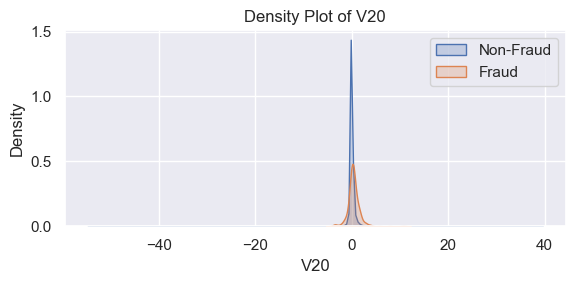

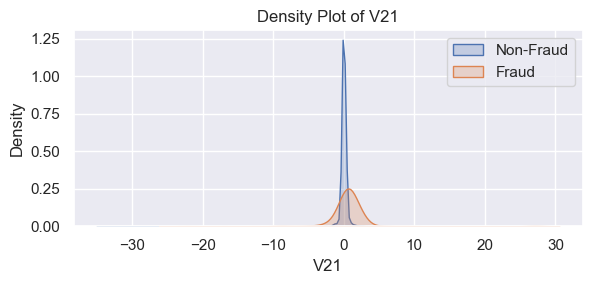

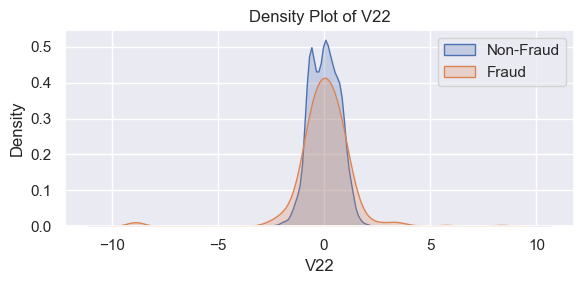

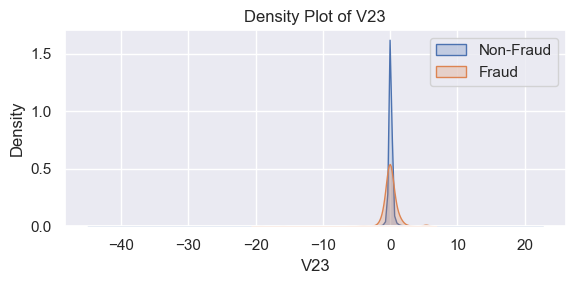

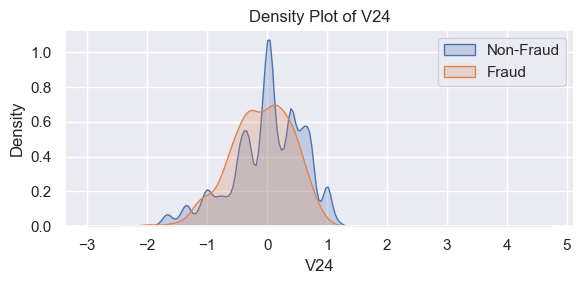

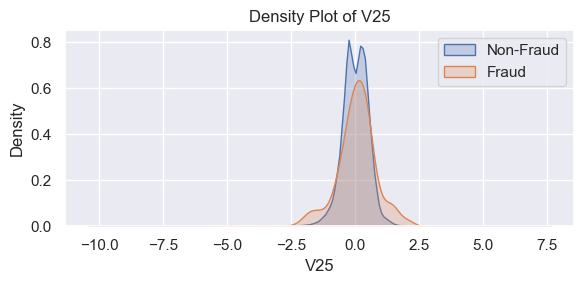

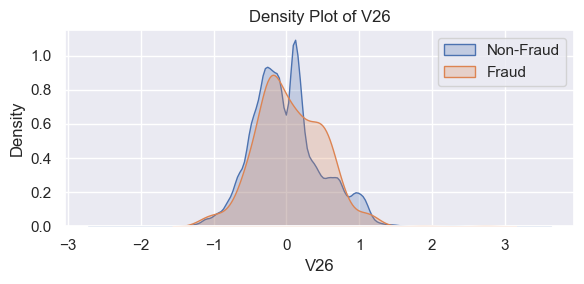

In [ ]:
# Credit Card Fraud Detection EDA


# Step 1: Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plots
sns.set_theme(style='darkgrid')  # fixed style error
sns.set(rc={'figure.figsize':(10,6)})

# Step 2: Load Dataset
df = pd.read_csv("creditcard.csv")

# Step 3: Basic Information
print("Dataset Shape:", df.shape)
print("\nDataset Info:")
print(df.info())
print("\nMissing Values:\n", df.isnull().sum())
print("\nStatistical Summary:")
print(df.describe())

# Step 4: Class Distribution (Fraud vs Non-Fraud)
print("\nClass Distribution:")
print(df['Class'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title("Class Distribution (0 = Non-Fraud, 1 = Fraud)")
plt.show()

# Step 5: Time vs Amount Distribution
fig, axs = plt.subplots(1, 2, figsize=(14,5))
sns.histplot(df['Time'], bins=50, ax=axs[0], kde=True)
axs[0].set_title('Distribution of Transaction Time')
sns.histplot(df['Amount'], bins=50, ax=axs[1], kde=True)
axs[1].set_title('Distribution of Transaction Amount')
plt.tight_layout()
plt.show()

# Step 6: Correlation Matrix
plt.figure(figsize=(12,8))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', annot=False, fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

# Correlation with Class
print("\nTop 10 Features Correlated with Class:")
print(corr['Class'].abs().sort_values(ascending=False)[1:11])

# Step 7: Fraud vs Non-Fraud Amount Distribution
plt.figure(figsize=(8,6))
sns.boxplot(x='Class', y='Amount', data=df)
plt.yscale('log')  # Log scale due to skewness
plt.title("Transaction Amount by Class")
plt.show()

# Step 8: PCA Features (V1-V28) - Density Plots for Fraud vs Non-Fraud
fraud = df[df['Class'] == 1]
nonfraud = df[df['Class'] == 0]

for col in df.columns[1:29]:
    plt.figure(figsize=(6,3))
    sns.kdeplot(nonfraud[col], label='Non-Fraud', fill=True)
    sns.kdeplot(fraud[col], label='Fraud', fill=True)
    plt.title(f'Density Plot of {col}')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Step 9: Time Feature - Does fraud occur at a specific time?
plt.figure(figsize=(10,6))
sns.histplot(df[df['Class'] == 1]['Time'], bins=100, color='red', label='Fraud', kde=True)
sns.histplot(df[df['Class'] == 0]['Time'], bins=100, color='green', label='Non-Fraud', kde=True)
plt.legend()
plt.title("Transaction Time - Fraud vs Non-Fraud")
plt.show()

# Step 10: Final Notes
print("\nSummary Insights:")
print("- Class is highly imbalanced (majority non-fraud).")
print("- Some features (like V14, V10, V17) show strong correlation with fraud.")
print("- Fraudulent transactions tend to have lower transaction amounts.")
print("- No missing values in the dataset.")
